# Anomalous Authentication Behavior Detection
## AI/ML Capstone Project — Daisy Wu

This notebook walks through the complete analysis pipeline for detecting anomalous
authentication behavior in enterprise security logs using the **LANL Cyber Security Dataset**.

**Evaluation Strategy**: We use two complementary metrics:
- **ROC AUC** — measures overall ranking quality (threshold-independent)
- **F2-Score** — measures detection quality at the operating threshold, weighting Recall 2x over Precision (threshold-dependent)

Together, these reveal whether a model is good at *ranking* threats AND good at *detecting* them in practice.

### Pipeline Overview

1. **Setup and Imports**
2. **Data Loading and Preprocessing**
3. **Exploratory Data Analysis**
4. **Feature Engineering**
5. **PCA and Clustering**
6. **Time Series Analysis**
7. **Data Preparation & SMOTE**
8. **Classification: KNN and Logistic Regression**
9. **Decision Trees, Random Forest, & SVM**
10. **Hyperparameter Tuning with GridSearchCV**
11. **Confusion Matrix Analysis**
12. **SHAP Value Analysis for Model Interpretability**
13. **Final Model Comparison**
14. **Conclusions and Next Steps**


## 1. Setup and Imports

In [35]:
# Uncomment and run this cell ONLY if using Google Colab to run

# import sys
# import os
# if 'google.colab' in sys.modules:
#     from google.colab import drive
#     drive.mount('/content/drive')

#     # Update this path if the project folder is located somewhere else in Google Drive
#     PROJECT_DIR = '/content/drive/MyDrive/AIML/dwu_captstone_project'
#     %cd {PROJECT_DIR}

#     # Install required packages
#     !pip install -r requirements.txt

In [36]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['PYTHONWARNINGS'] = 'ignore'

from src.data_preprocessing import (
    load_auth_data, load_auth_data_sampled, load_redteam_labels,
    clean_data, label_redteam_events, save_processed_data
)
from src.feature_engineering import build_feature_matrix, FEATURE_COLUMNS, TARGET_COLUMN
from src.eda import (
    generate_summary_statistics, run_full_eda,
    plot_login_distribution, plot_success_failure_ratio,
    plot_hourly_pattern, plot_top_users,
    plot_auth_type_distribution, plot_redteam_timeline,
    plot_correlation_matrix
)
from src.clustering_pca import (
    apply_pca, plot_explained_variance,
    find_optimal_clusters, apply_kmeans, plot_pca_clusters
)
from src.time_series import (
    aggregate_login_timeseries, decompose_timeseries,
    detect_temporal_anomalies, plot_timeseries_with_anomalies
)
from src.model_selection import (
    compare_models, tune_regularization,
    plot_learning_curve, evaluate_model, save_model
)
from src.classification import (
    train_knn, find_optimal_k, train_logistic_regression,
    plot_roc_curves, plot_confusion_matrices, print_classification_report
)
from src.decision_trees import (
    train_decision_tree, tune_tree_depth,
    visualize_tree, extract_rules, get_feature_importance
)
from src.utils import load_processed_data, prepare_train_test, print_section

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

print('All imports successful!')

All imports successful!


## 2. Data Loading and Preprocessing

The LANL dataset contains ~1.6 billion authentication events over 58 days.
We start with a sample for development, then scale up.

**Before running:** Download the LANL dataset and place `auth.txt.gz` and `redteam.txt.gz` in `data/raw/`.

In [37]:
# Load a stratified sample spread across the full 58-day time range.
# This ensures we capture red team events and have enough temporal coverage
# for time series analysis. Adjust target_rows to trade speed vs. coverage.
SAMPLE_SIZE = 1_000_000

df_raw = load_auth_data_sampled(target_rows=SAMPLE_SIZE)
df_raw.head(10)

Loading stratified sample (~1,000,000 rows, rate=0.000607) from /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/raw/auth.txt.gz...
Loading red team labels from /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/raw/redteam.txt.gz...
  Loaded 749 red team events
  ... processed 100M rows, collected 60,706 so far
  ... processed 200M rows, collected 121,636 so far
  ... processed 300M rows, collected 182,629 so far
  ... processed 400M rows, collected 243,295 so far
  ... processed 500M rows, collected 303,995 so far
  ... processed 600M rows, collected 364,662 so far
  ... processed 700M rows, collected 425,322 so far
  ... processed 800M rows, collected 485,982 so far
  ... processed 900M rows, collected 546,642 so far
  ... processed 1000M rows, collected 607,302 so far
  Loaded 638,499 rows, 9 columns
  Time range: 3 – 5011199 seconds (58.0 days)


,time,src_user_domain,dst_user_domain,src_computer,dst_computer,auth_type,logon_type,auth_orientation,outcome
0,3,C1297$@DOM1,SYSTEM@C1297,C1297,C1297,Negotiate,Service,LogOn,Success
1,4,C1381$@DOM1,SYSTEM@C1381,C1381,C1381,Negotiate,Service,LogOn,Success
2,10,U66@DOM1,U66@DOM1,C1998,C1998,NaN,Network,LogOff,Success
3,14,U75@DOM1,U75@DOM1,C1710,C1710,NaN,Interactive,LogOff,Success
4,33,C357$@DOM1,C357$@DOM1,C612,C612,NaN,Network,LogOff,Success
5,87,C2899$@DOM1,C2899$@DOM1,C612,C612,NaN,Network,LogOff,Success
6,108,C419$@DOM1,C419$@DOM1,C586,C586,NaN,Network,LogOff,Success
7,154,U63@DOM1,U63@DOM1,C1755,C1755,Kerberos,Network,LogOn,Success
8,162,C1900$@DOM1,C1900$@DOM1,C1900,C2106,Kerberos,Network,LogOn,Success
9,163,C2941$@DOM1,C2941$@DOM1,C457,C457,NaN,Network,LogOff,Success


In [38]:
# Load red team labels (known malicious events)
redteam = load_redteam_labels()
print(f"\nRed team event sample:")
redteam.head()

Loading red team labels from /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/raw/redteam.txt.gz...
  Loaded 749 red team events

Red team event sample:


,time,src_user_domain,src_computer,dst_computer
0,150885,U620@DOM1,C17693,C1003
1,151036,U748@DOM1,C17693,C305
2,151648,U748@DOM1,C17693,C728
3,151993,U6115@DOM1,C17693,C1173
4,153792,U636@DOM1,C17693,C294


In [39]:
# Clean the data: parse user@domain, convert success/failure, add time features
df = clean_data(df_raw)
df.head()

  Cleaned data: 638,499 rows, 19 columns


,time,src_user_domain,dst_user_domain,src_computer,dst_computer,auth_type,logon_type,auth_orientation,outcome,src_user,src_domain,dst_user,dst_domain,success,hour,day,day_of_week,is_off_hours,is_weekend
0,3,C1297$@DOM1,SYSTEM@C1297,C1297,C1297,Negotiate,Service,LogOn,Success,C1297$,DOM1,SYSTEM,C1297,1,0,0,0,1,0
1,4,C1381$@DOM1,SYSTEM@C1381,C1381,C1381,Negotiate,Service,LogOn,Success,C1381$,DOM1,SYSTEM,C1381,1,0,0,0,1,0
2,10,U66@DOM1,U66@DOM1,C1998,C1998,NaN,Network,LogOff,Success,U66,DOM1,U66,DOM1,1,0,0,0,1,0
3,14,U75@DOM1,U75@DOM1,C1710,C1710,NaN,Interactive,LogOff,Success,U75,DOM1,U75,DOM1,1,0,0,0,1,0
4,33,C357$@DOM1,C357$@DOM1,C612,C612,NaN,Network,LogOff,Success,C357$,DOM1,C357$,DOM1,1,0,0,0,1,0


In [40]:
# Label red team events as suspicious
df = label_redteam_events(df, redteam)

# Save cleaned data for reuse
save_processed_data(df, 'auth_cleaned.parquet')

  Labeled 702 suspicious events (0.1099% of total)
  Saved 638,499 rows to /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/processed/auth_cleaned.parquet


In [41]:
# load data from parquet file
df = load_processed_data('auth_cleaned.parquet')

## 3. Exploratory Data Analysis

In [42]:
# Summary statistics
generate_summary_statistics(df)

Dataset shape: (638499, 20)

Time range: 3 – 5011199 seconds
Duration: 58.0 days

Unique source users: 22,249
Unique destination users: 22,228
Unique source computers: 13,501
Unique destination computers: 11,720

Authentication types: {'Kerberos': 220069, 'Negotiate': 33358, 'NTLM': 30868, 'MICROSOFT_AUTHENTICATION_PACKAGE_V1_0': 457, 'MICROSOFT_AUTHENTICATION_PACKAG': 15, 'MICROSOFT_AUTHENTICATION_PACKAGE': 14, 'MICROSOFT_AUTHENTICATION_PACKAGE_V1_': 12, 'MICROSOFT_AUTHENTICATION_PACK': 12, 'MICROSOFT_AUTHENTICATION_PACKAGE_V1': 8, 'MICROSOFT_AUTHENTICATION_PACKAGE_V': 4, 'MICROSOFT_AUTHENTICATION_PACKAGE_': 4, 'MICROSOFT_AUTHENTICATION_PA': 2, 'ACRONIS_RELOGON_AUTHENTICATION_PACKAGE': 1, 'MICROSOFT_AUTHENTICATION_PACKA': 1}
Logon types: {'Network': 514066, 'Service': 29621, 'Unlock': 2344, 'Interactive': 1275, 'Batch': 1065, 'NewCredentials': 665, 'NetworkCleartext': 238, 'RemoteInteractive': 83, 'CachedInteractive': 70}

Outcome distribution:
outcome
Success    630828
Fail         7

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_daily_volume.png


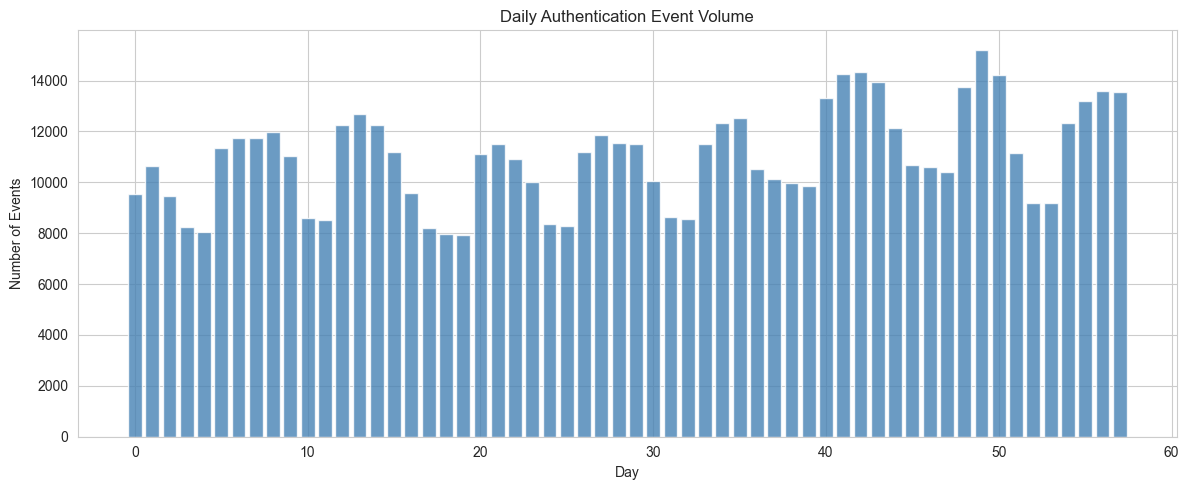

In [43]:
# Login volume over time
plot_login_distribution(df)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_success_failure.png


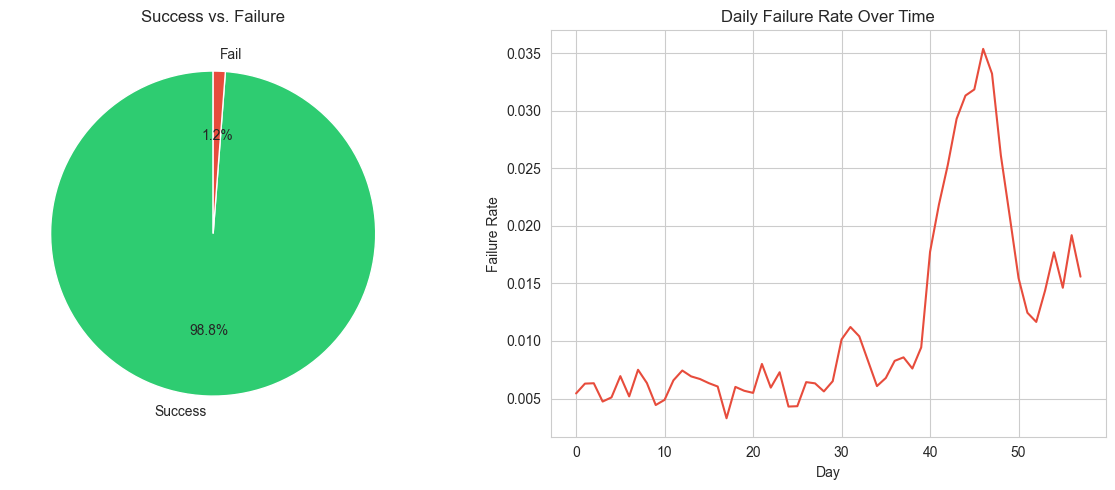

In [44]:
# Success vs. failure breakdown
plot_success_failure_ratio(df)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_hourly_pattern.png


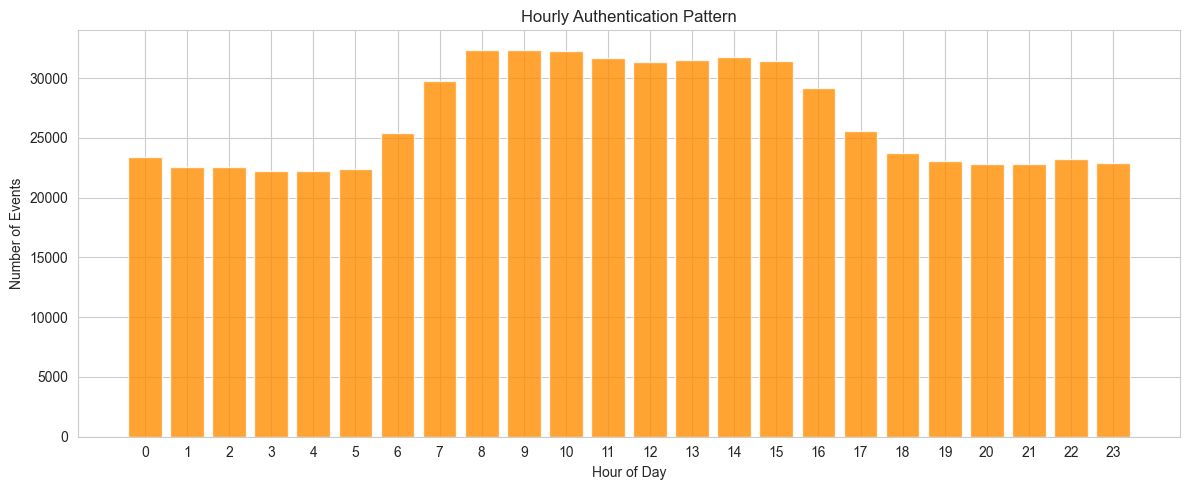

In [45]:
# Hourly login pattern
plot_hourly_pattern(df)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_top_users.png


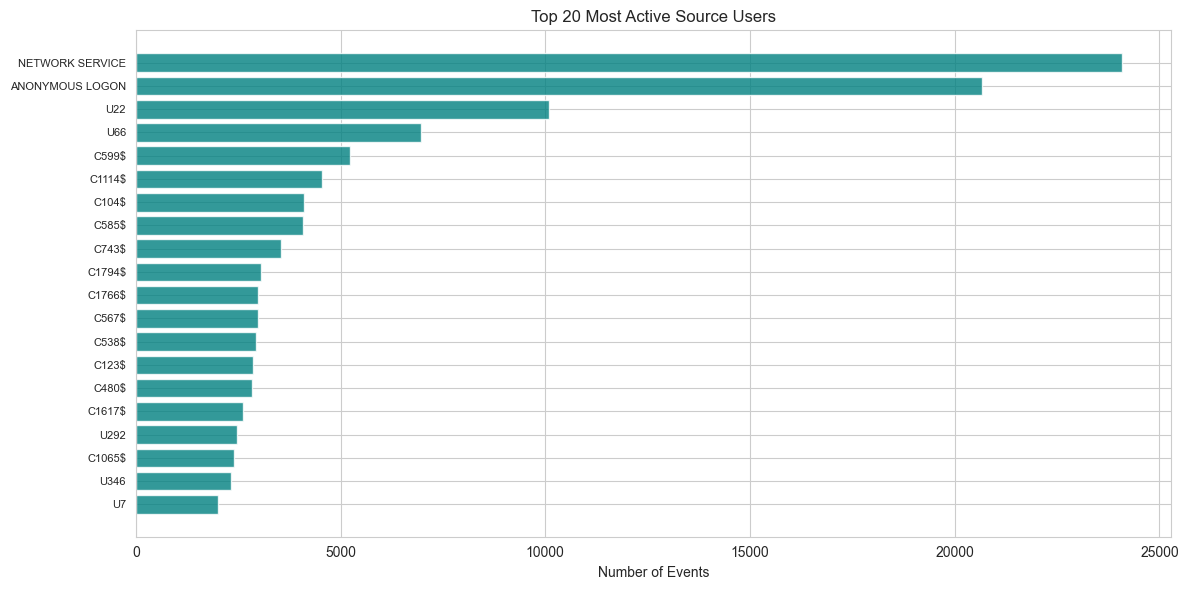

In [46]:
# Most active users
plot_top_users(df, top_n=20)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_auth_types.png


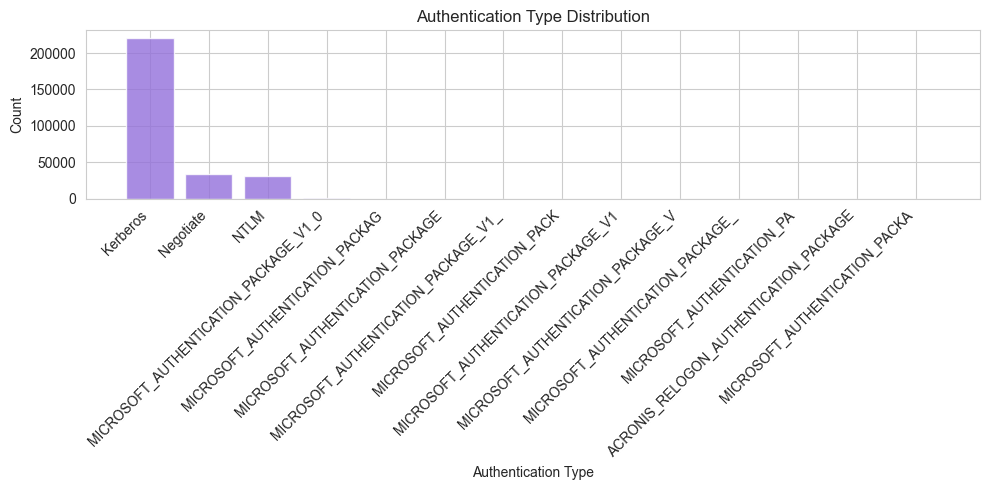

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_logon_types.png


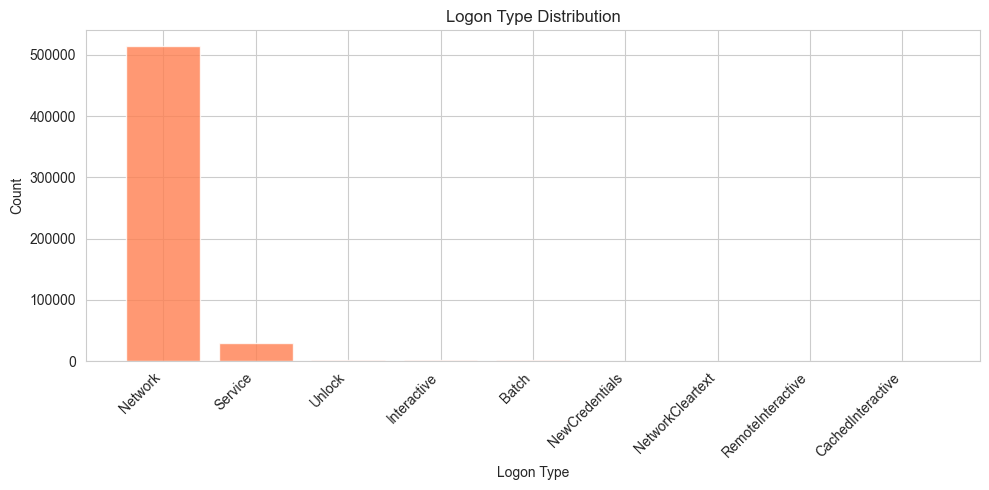

In [47]:
# Authentication and logon type distributions
plot_auth_type_distribution(df)
from src.eda import plot_logon_type_distribution
plot_logon_type_distribution(df)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_redteam_timeline.png


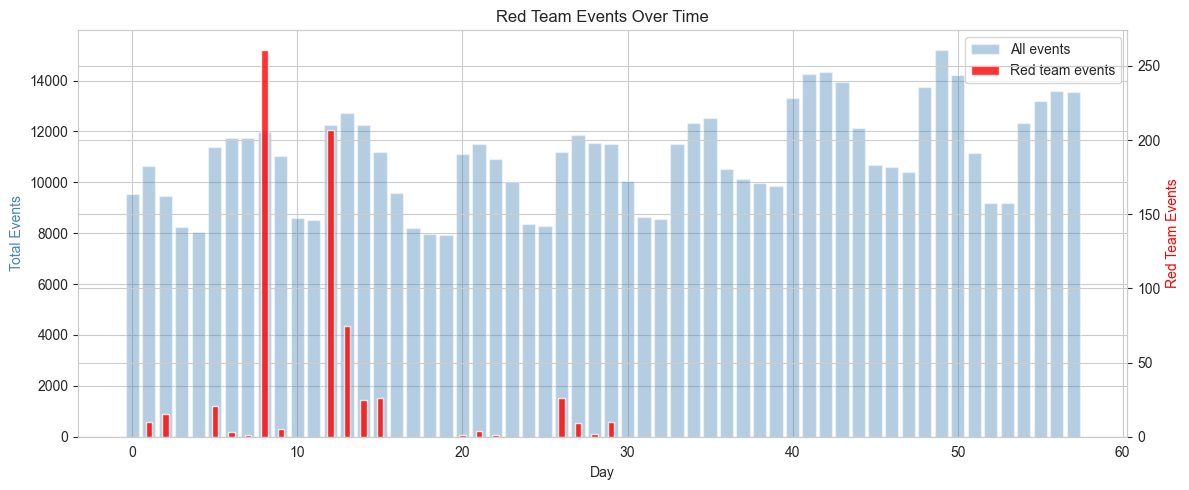

In [48]:
# Red team events timeline
plot_redteam_timeline(df)

## 4. Feature Engineering

Engineer behavioral features from raw log fields:

- **Temporal**: hour, day, off-hours flag, weekend flag, time since last login
- **Frequency**: login counts over 1h/6h/24h windows, daily failure ratio
- **Diversity**: distinct computers, auth types, logon types per user per day
- **Baseline**: total events, mean daily events, new destination flag

In [49]:
print("Building feature matrix (this may take a few minutes)...")
df_features = build_feature_matrix(df)
df_features.head(10)

Building feature matrix (this may take a few minutes)...
  Computing rolling login counts (1h, 6h, 24h)...
  Computing failure counts and ratios...
  Computing diversity features (unique computers, auth types)...
  Computing time-since-last-login...
  Computing new-destination flag...
  Computing velocity (events per minute, 10-min window)...
  Feature matrix: 638,499 rows × 17 columns
  Suspicious events: 702 (0.1099%)


,hour,day_of_week,is_off_hours,is_weekend,success,login_count_1h,login_count_6h,login_count_24h,fail_count_1h,fail_ratio_24h,unique_dst_computers_24h,unique_auth_types_24h,unique_logon_types_24h,time_since_last_login,is_new_dst_computer,events_per_minute_10m,is_suspicious
0,0,0,1,0,1,1,1,1,0,0.0,1,1,1,0.0,1,0.1,0
1,0,0,1,0,1,1,1,1,0,0.0,3,1,2,0.0,1,0.1,0
2,0,0,1,0,1,1,1,1,0,0.0,58,2,1,0.0,1,0.1,0
3,0,0,1,0,1,1,1,1,0,0.0,2,0,2,0.0,1,0.1,0
4,0,0,1,0,1,1,1,1,0,0.0,2,0,1,0.0,1,0.1,0
5,0,0,1,0,1,1,1,1,0,0.0,1,0,1,0.0,1,0.1,0
6,0,0,1,0,1,1,1,1,0,0.0,2,1,1,0.0,1,0.1,0
7,0,0,1,0,1,1,1,1,0,0.0,3,3,2,0.0,1,0.1,0
8,0,0,1,0,1,1,1,1,0,0.0,3,1,1,0.0,1,0.1,0
9,0,0,1,0,1,1,1,1,0,0.0,1,0,1,0.0,1,0.1,0


In [50]:
# Save feature matrix for reuse
save_processed_data(df_features, 'auth_features.parquet')



  Saved 638,499 rows to /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/processed/auth_features.parquet


In [51]:
# reload feature matrix
df_features = load_processed_data('auth_features.parquet')

print(f"\nFeature columns: {[c for c in df_features.columns if c != TARGET_COLUMN]}")
print(f"Target column: {TARGET_COLUMN}")
print(f"\nClass distribution:")
print(df_features[TARGET_COLUMN].value_counts())


Feature columns: ['hour', 'day_of_week', 'is_off_hours', 'is_weekend', 'success', 'login_count_1h', 'login_count_6h', 'login_count_24h', 'fail_count_1h', 'fail_ratio_24h', 'unique_dst_computers_24h', 'unique_auth_types_24h', 'unique_logon_types_24h', 'time_since_last_login', 'is_new_dst_computer', 'events_per_minute_10m']
Target column: is_suspicious

Class distribution:
is_suspicious
0    637797
1       702
Name: count, dtype: int64


  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_correlation_matrix.png


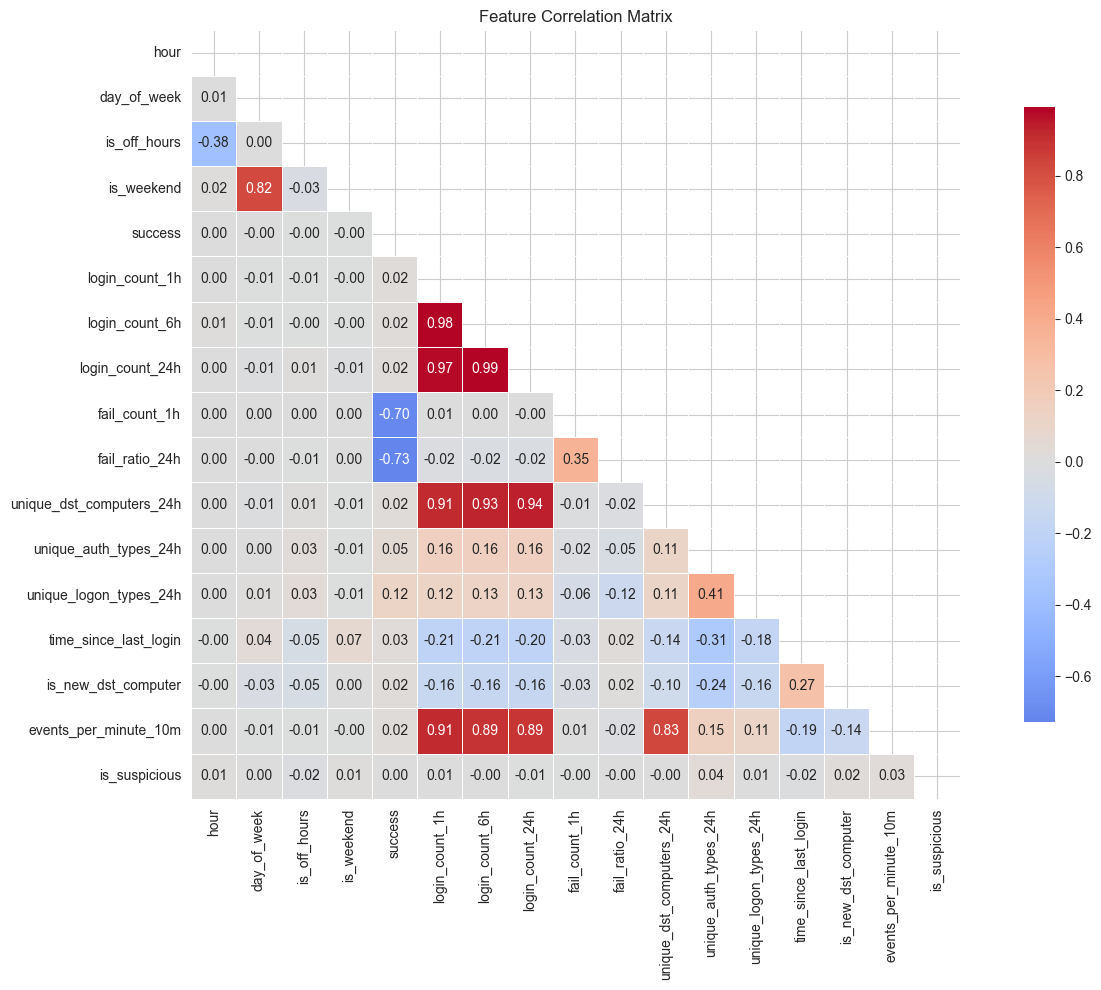

In [52]:
# Correlation matrix of engineered features
plot_correlation_matrix(df_features)

## 5. PCA and Clustering

Use PCA to reduce the high-dimensional feature space for visualization.
Apply K-Means clustering to discover natural groupings of login behavior.

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/pca_explained_variance.png


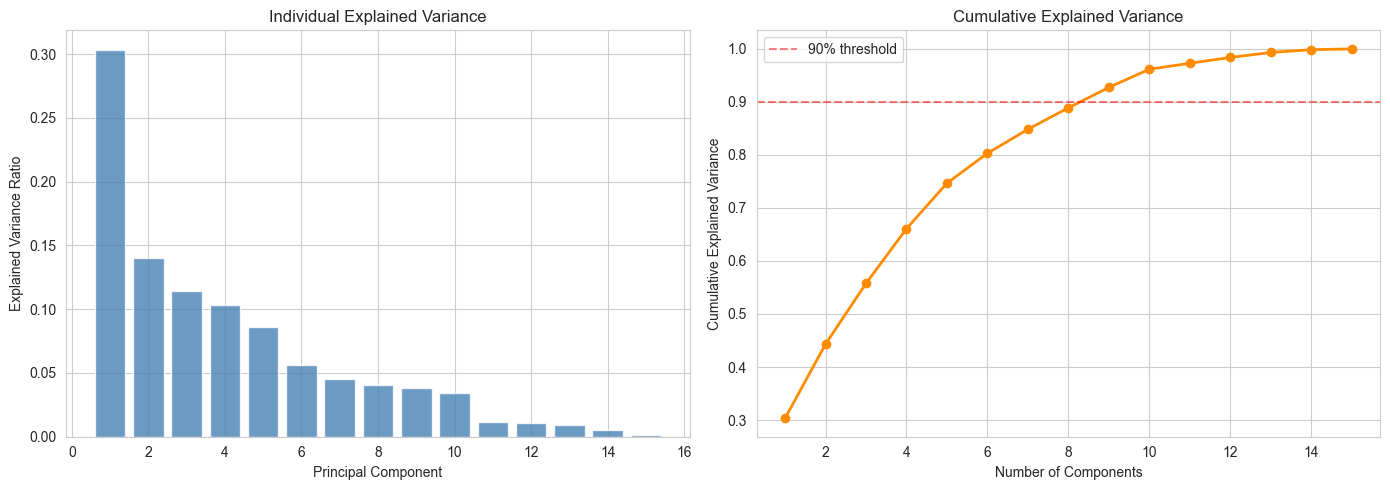

  PC1: 0.3034 (cumulative: 0.3034)
  PC2: 0.1398 (cumulative: 0.4432)
  PC3: 0.1144 (cumulative: 0.5576)
  PC4: 0.1031 (cumulative: 0.6607)
  PC5: 0.0858 (cumulative: 0.7465)
  PC6: 0.0562 (cumulative: 0.8028)
  PC7: 0.0452 (cumulative: 0.8480)
  PC8: 0.0405 (cumulative: 0.8885)
  PC9: 0.0384 (cumulative: 0.9269)
  PC10: 0.0344 (cumulative: 0.9613)
  PC11: 0.0112 (cumulative: 0.9725)
  PC12: 0.0110 (cumulative: 0.9834)
  PC13: 0.0094 (cumulative: 0.9928)
  PC14: 0.0053 (cumulative: 0.9981)
  PC15: 0.0015 (cumulative: 0.9996)


In [53]:
# Separate features and target
X_all = df_features.drop(columns=[TARGET_COLUMN]).values
y_all = df_features[TARGET_COLUMN].values
feature_names = [c for c in df_features.columns if c != TARGET_COLUMN]

# Explained variance analysis
plot_explained_variance(X_all)

In [54]:
# Apply PCA (2 components for visualization)
X_pca, pca, pca_scaler = apply_pca(X_all, n_components=2)

  PCA: 16 features → 2 components
  Explained variance: 0.4432


  K=2: inertia=1928902, silhouette=0.8991
  K=3: inertia=655812, silhouette=0.9132
  K=4: inertia=342107, silhouette=0.7944
  K=5: inertia=258157, silhouette=0.7945
  K=6: inertia=187811, silhouette=0.5817
  K=7: inertia=149312, silhouette=0.5107
  K=8: inertia=123724, silhouette=0.5038
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/clustering_elbow_silhouette.png


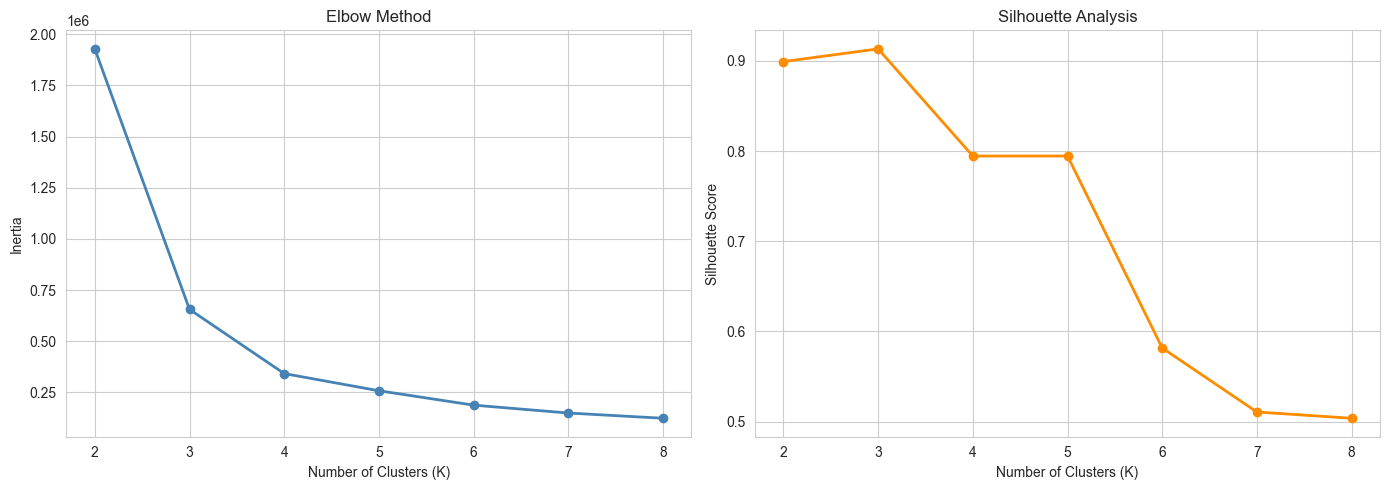

In [55]:
# Find optimal number of clusters
K_range, inertias, silhouettes = find_optimal_clusters(X_pca, max_k=8)

  K-Means (K=3): silhouette=0.9127
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/pca_clusters.png


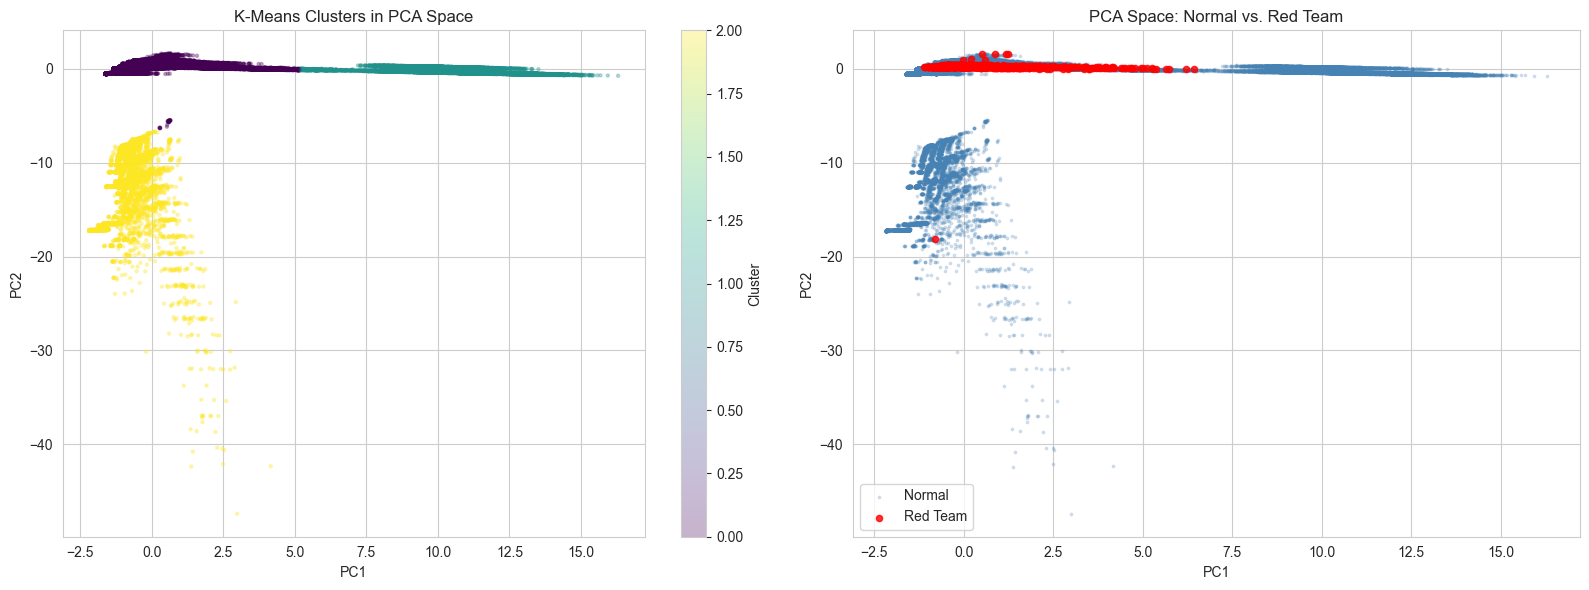

In [56]:
# Apply K-Means and visualize with red team overlay
labels, kmeans = apply_kmeans(X_pca, n_clusters=3)
plot_pca_clusters(X_pca, labels, suspicious=y_all)

In [57]:
# Analyze cluster composition
cluster_df = pd.DataFrame({'cluster': labels, 'is_suspicious': y_all})
print("Cluster composition:")
print(cluster_df.groupby('cluster')['is_suspicious'].agg(['count', 'sum', 'mean']))
print("\n'mean' = proportion of red team events in each cluster")

Cluster composition:
          count  sum      mean
cluster                       
0        609070  694  0.001139
1         21787    7  0.000321
2          7642    1  0.000131

'mean' = proportion of red team events in each cluster


## 6. Time Series Analysis
Model temporal trends in login behavior and detect sudden deviations.

In [58]:
# Aggregate to hourly time series
ts = aggregate_login_timeseries(df, freq_seconds=3600)
print(f"Time series: {len(ts)} hourly bins")
print(f"Mean events/hour: {ts.mean():.0f}")
print(f"Max events/hour: {ts.max():.0f}")

Time series: 1392 hourly bins
Mean events/hour: 459
Max events/hour: 1069


  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/ts_decomposition.png


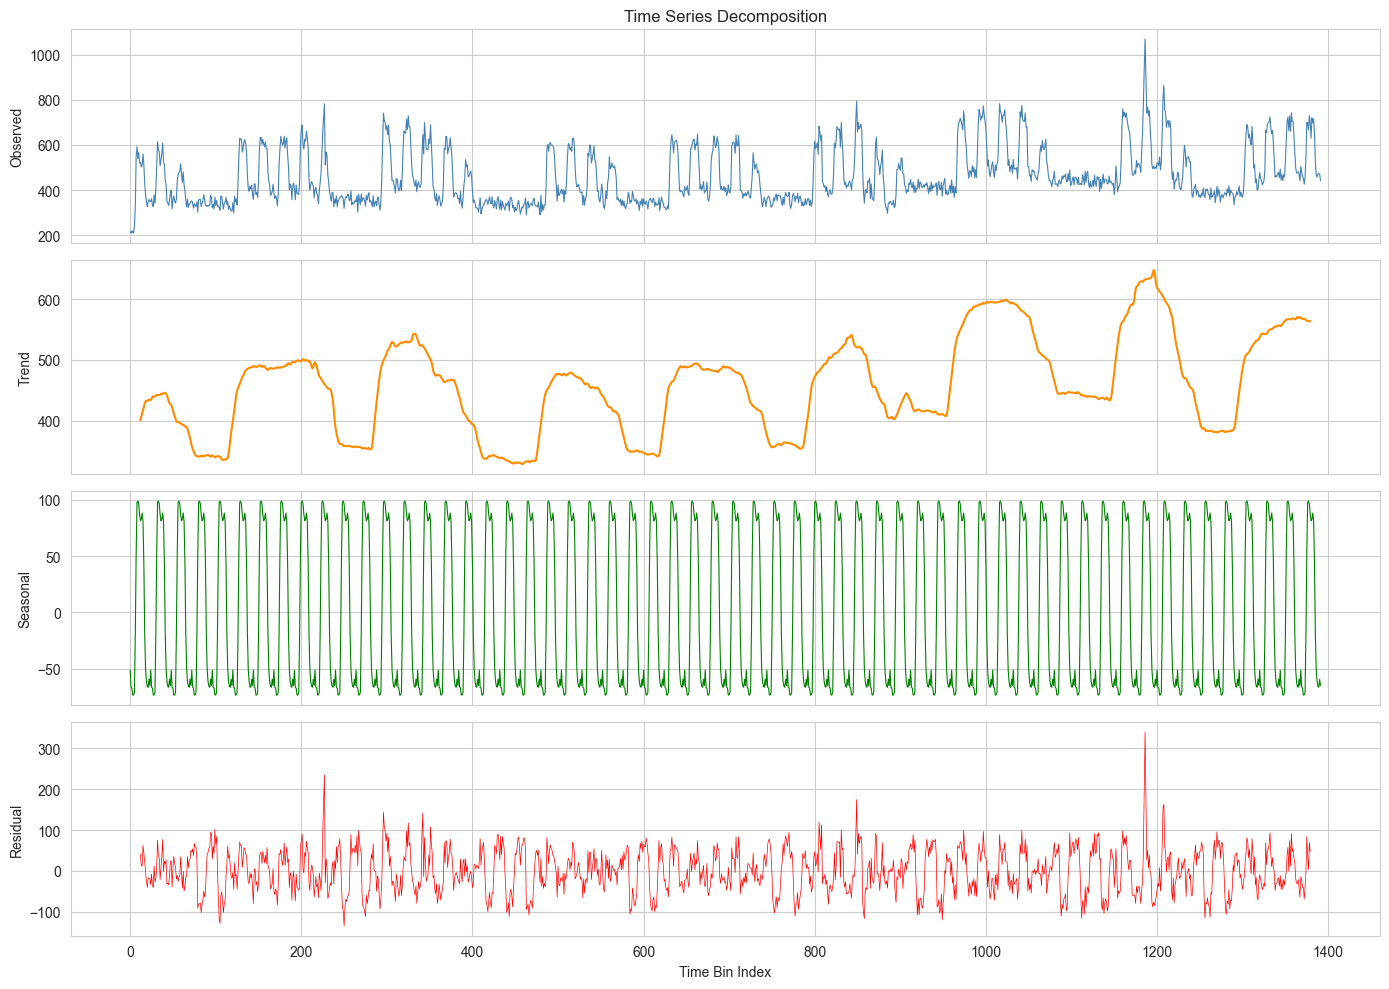

In [59]:
# Seasonal decomposition (daily seasonality = 24 hours)
decomposition = decompose_timeseries(ts, period=24)

  Detected 0 anomalous time bins (threshold=3.0, window=24)
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/ts_anomalies.png


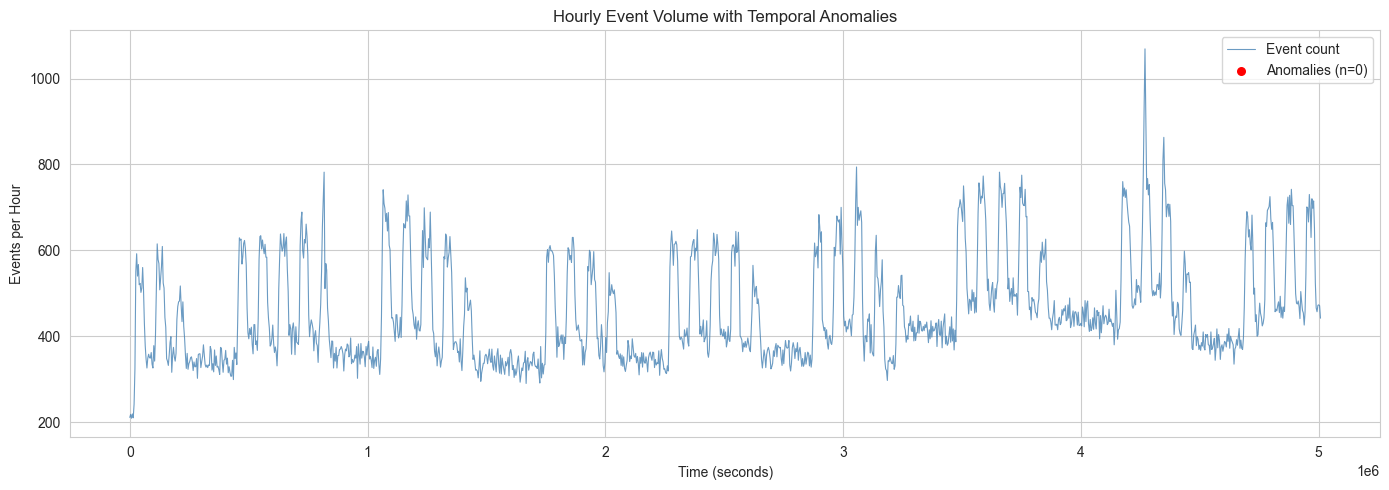

In [60]:
# Detect temporal anomalies using z-score
anomalies = detect_temporal_anomalies(ts, window=24, threshold=3.0)
plot_timeseries_with_anomalies(ts, anomalies)

## 7. Data Preparation & SMOTE

Before training our models, we need to split the data into training and test sets and scale the features. Because our dataset is extremely imbalanced (~0.1% positive class), we apply the **SMOTE (Synthetic Minority Over-sampling Technique)** strategy to the training data. SMOTE synthesizes new examples for the minority class (red team events) by interpolating between existing positive samples, which helps the models learn the minority class better without simply memorizing duplicated rows.

In [61]:
# Prepare train/test split, scale features, and apply SMOTE to the training set
X_train, X_test, y_train, y_test, scaler, feat_names = prepare_train_test(df_features, apply_smote=True)

  Train: 510,799 rows (562 positive)
  Test:  127,700 rows (140 positive)
  Applying SMOTE to balance the training data...
  After SMOTE: Train has 1,020,474 rows (510,237 positive)


Cross-validation model comparison:
  Baseline (Stratified): F2 = 0.4998, AUC = 0.4999, Recall = 0.4997, Prec = 0.4999, Time = 0.0516s
  Logistic Regression (L2): F2 = 0.9077, AUC = 0.9660, Recall = 0.9106, Prec = 0.8962, Time = 0.9534s
  Logistic Regression (L1): F2 = 0.9078, AUC = 0.9660, Recall = 0.9107, Prec = 0.8963, Time = 22.0672s
  KNN (k=5): F2 = 0.9969, AUC = 0.9982, Recall = 0.9977, Prec = 0.9937, Time = 0.0405s
  Decision Tree (depth=5): F2 = 0.8935, AUC = 0.9600, Recall = 0.8940, Prec = 0.8917, Time = 4.3703s
  Random Forest: F2 = 0.9218, AUC = 0.9819, Recall = 0.9203, Prec = 0.9281, Time = 30.3420s
  Support Vector Machine: F2 = 0.9092, AUC = 0.9651, Recall = 0.9128, Prec = 0.8948, Time = 2.7124s

MODEL COMPARISON — Two Complementary Metrics
------------------------------------------------------------------------------------------------------------------------
  ROC AUC  = Overall discrimination ability across all thresholds (threshold-independent)
  F2-Score = Recall weig

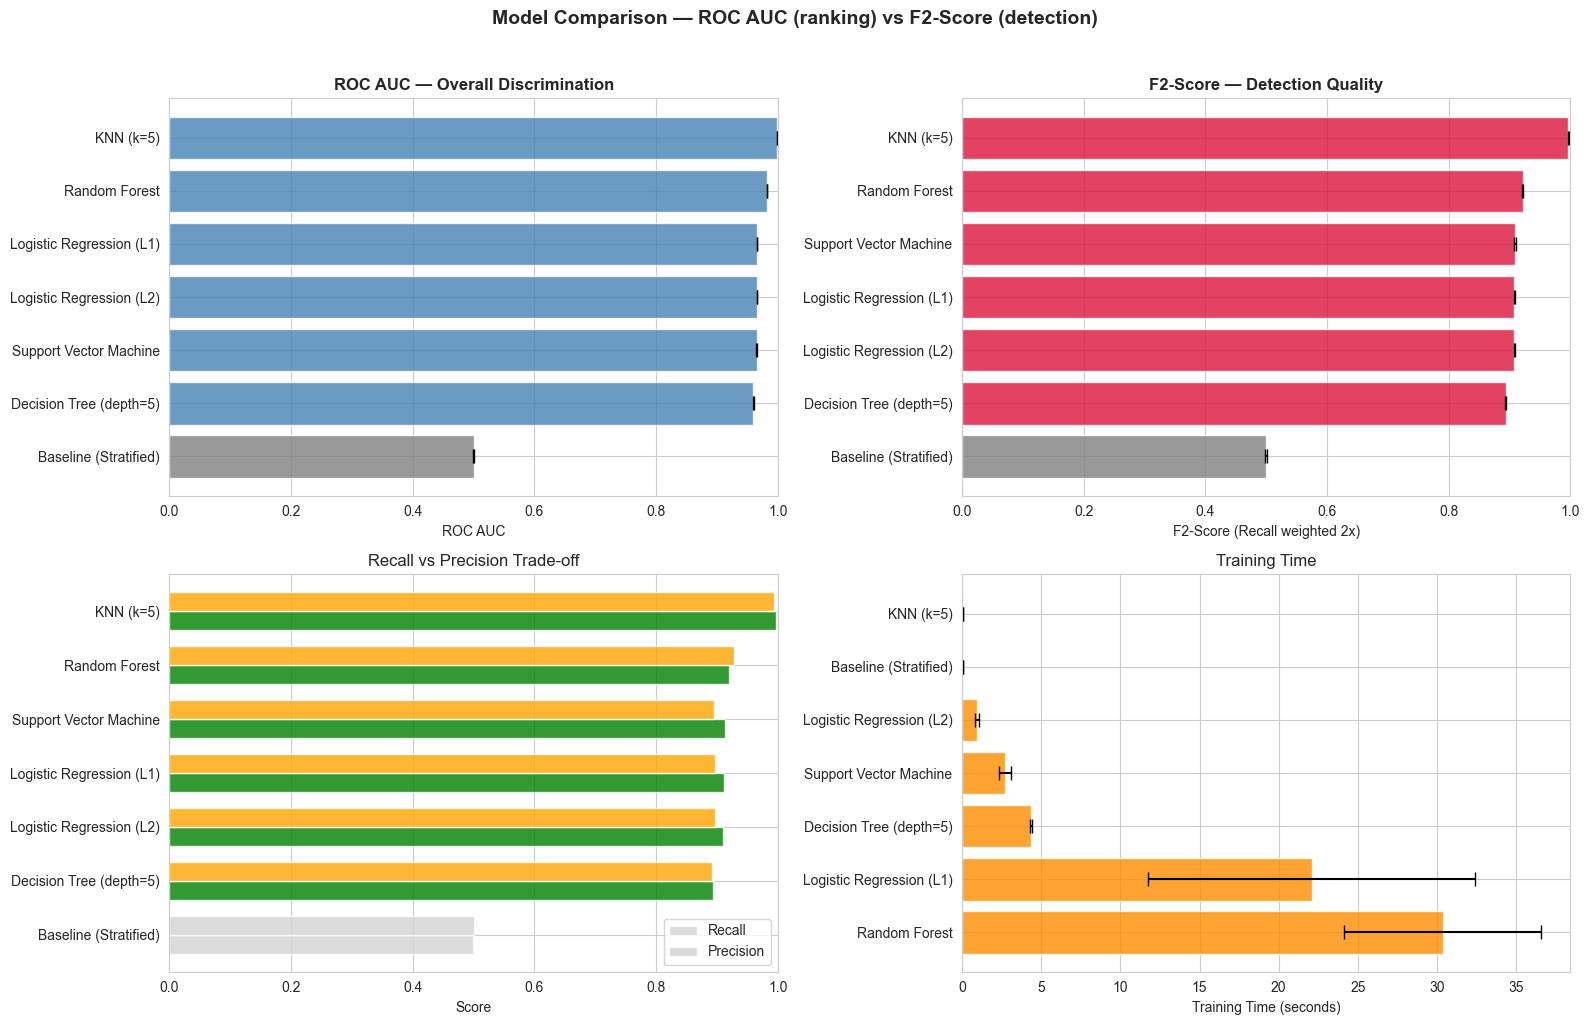

In [62]:
# Compare all candidate models
import warnings
warnings.filterwarnings('ignore')

print("Cross-validation model comparison:")
results = compare_models(X_train, y_train, cv=5)

  Best C = 78.475997 (AUC = 0.9660)
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/regularization_tuning.png


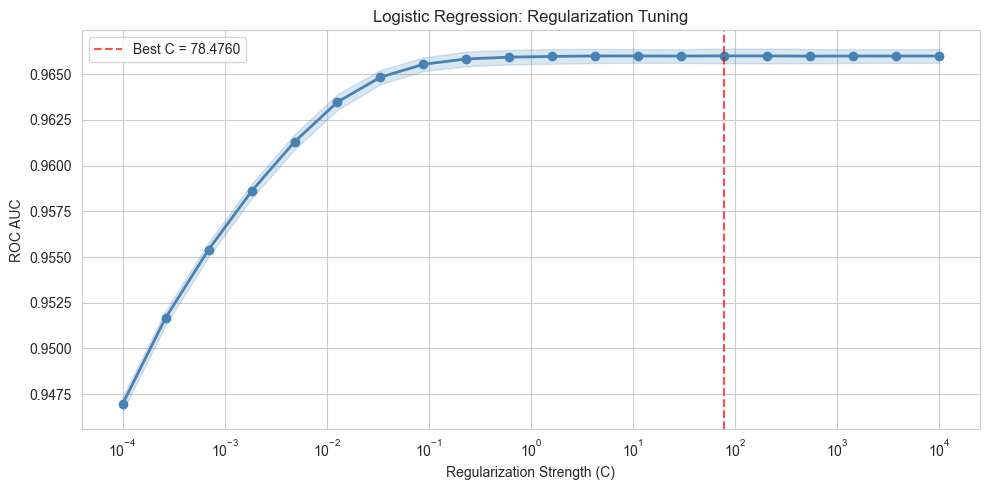

In [63]:
# Tune regularization (C parameter) for logistic regression
best_lr, reg_results = tune_regularization(X_train, y_train, cv=5)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/learning_curve.png


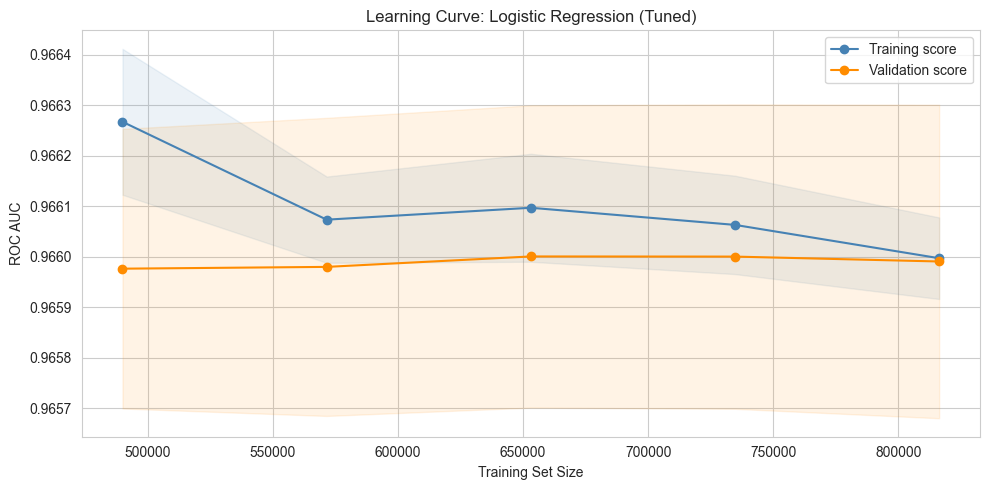

In [64]:
# Learning curve for the tuned logistic regression
plot_learning_curve(best_lr, X_train, y_train, 'Logistic Regression (Tuned)')

## 8. Classification: KNN and Logistic Regression

Build baseline classifiers:

- **KNN** captures local behavioral similarities
- **Logistic Regression** provides interpretable feature weights

**Evaluation Metrics**:
- **ROC AUC**: How well does the model rank threats above normal events? (threshold-independent)
- **F2-Score**: How well does the model detect threats at the default threshold? (Recall weighted 2x over Precision)


  k=1: AUC = 0.9974 ± 0.0001
  k=2: AUC = 0.9978 ± 0.0001
  k=3: AUC = 0.9980 ± 0.0001
  k=4: AUC = 0.9981 ± 0.0001
  k=5: AUC = 0.9982 ± 0.0002
  k=6: AUC = 0.9985 ± 0.0001
  k=7: AUC = 0.9985 ± 0.0001
  k=8: AUC = 0.9986 ± 0.0001
  k=9: AUC = 0.9986 ± 0.0001

  Best k = 9 (AUC = 0.9986)
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/knn_optimal_k.png


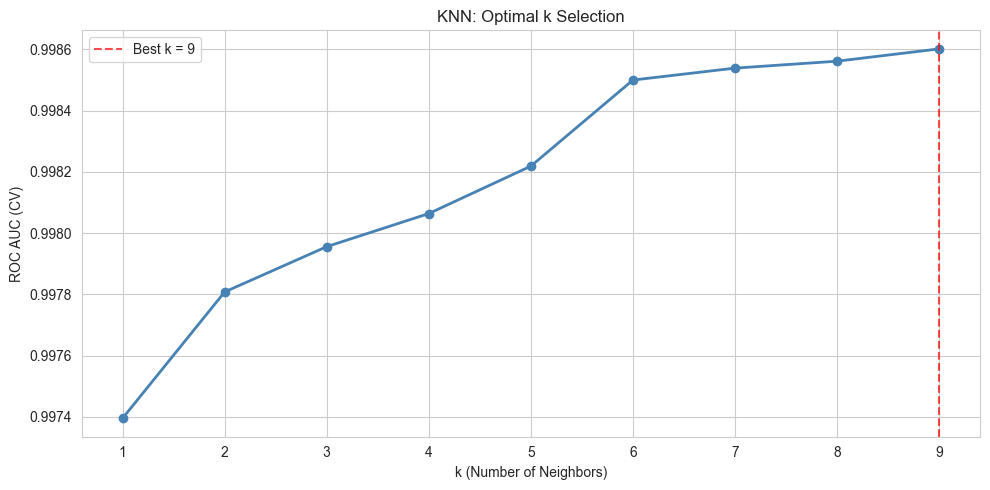

In [65]:
# Find optimal k for KNN
best_k, k_scores = find_optimal_k(X_train, y_train, k_range=range(1, 10), cv=5)

In [66]:
# Train KNN with optimal k
knn = train_knn(X_train, y_train, n_neighbors=best_k)
print_classification_report(knn, X_test, y_test, 'KNN')

  Trained KNN with k=9 in 0.0503s

  Classification Report — KNN
  --------------------------------------------------
  Train Time: 0.0503 seconds
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    127560
           1       0.08      0.65      0.15       140

    accuracy                           0.99    127700
   macro avg       0.54      0.82      0.57    127700
weighted avg       1.00      0.99      0.99    127700



  Trained Logistic Regression (C=78.4760)

  Feature Coefficients (sorted by magnitude):
    - login_count_24h                -23.2113
    + unique_dst_computers_24h       +8.2402
    + login_count_1h                 +5.8488
    + login_count_6h                 +2.3323
    + is_weekend                     +2.0953
    + unique_auth_types_24h          +1.8958
    + events_per_minute_10m          +1.8727
    - day_of_week                    -1.6646
    + success                        +1.6082
    - is_off_hours                   -1.1669
    - fail_count_1h                  -0.8149
    + is_new_dst_computer            +0.8092
    - fail_ratio_24h                 -0.7830
    + hour                           +0.5939
    - time_since_last_login          -0.4696
    - unique_logon_types_24h         -0.4459
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/lr_coefficients.png


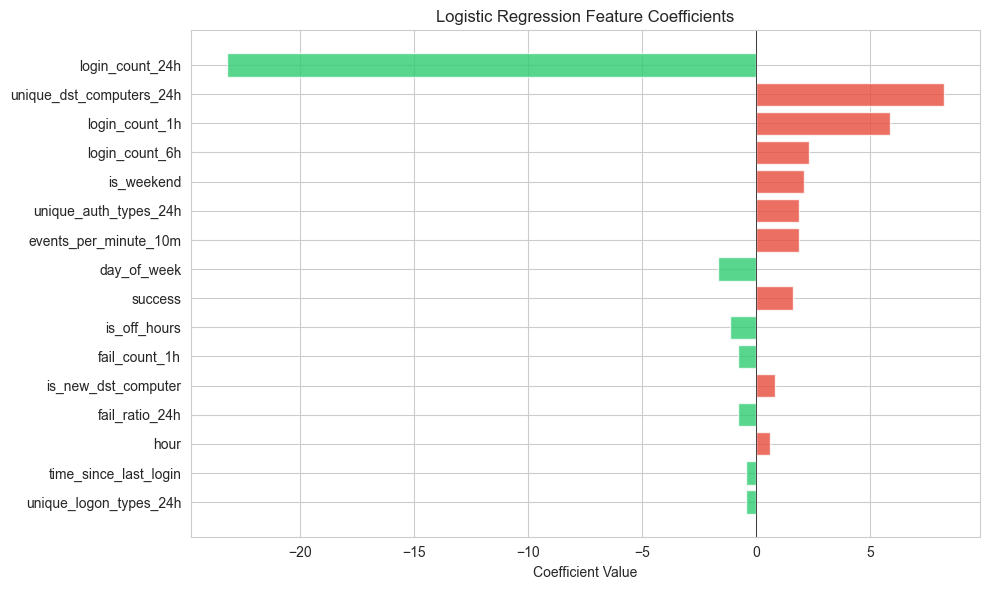


  Classification Report — Logistic Regression
  --------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.89      0.94    127560
           1       0.01      0.88      0.02       140

    accuracy                           0.89    127700
   macro avg       0.50      0.89      0.48    127700
weighted avg       1.00      0.89      0.94    127700



In [67]:
# Train Logistic Regression with feature coefficient analysis
lr = train_logistic_regression(X_train, y_train, feature_names=feat_names, C=best_lr.C)
print_classification_report(lr, X_test, y_test, 'Logistic Regression')

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/roc_curves.png


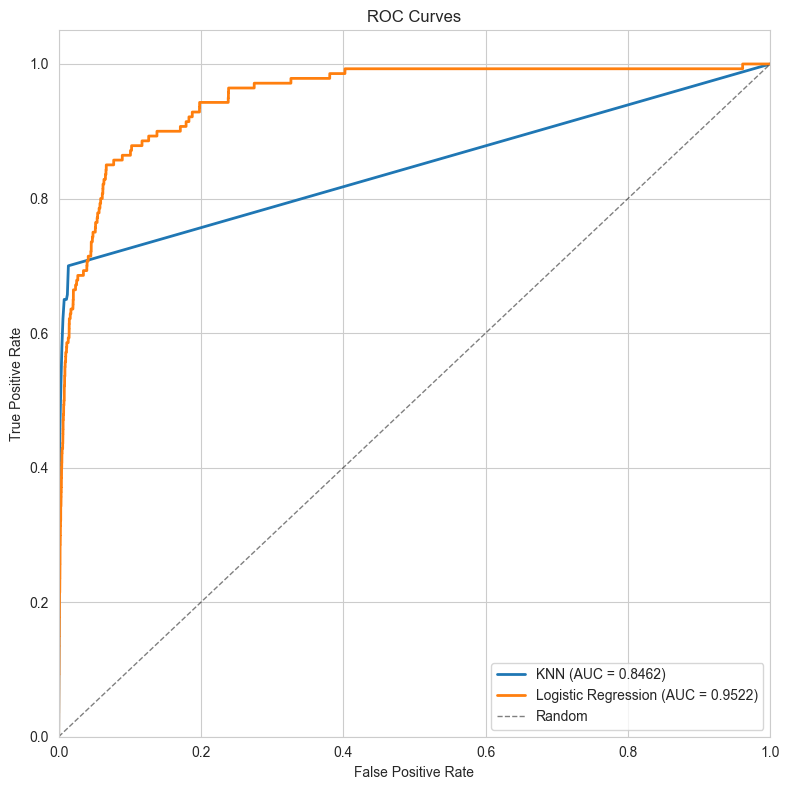

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/confusion_matrices.png


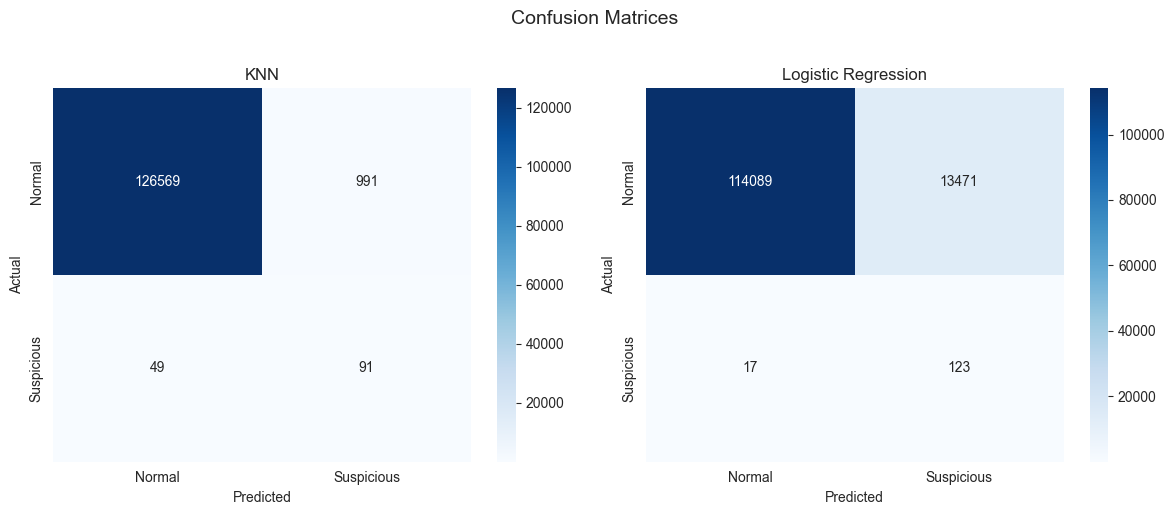


  Classification Report — KNN
  --------------------------------------------------
  Train Time: 0.0503 seconds
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    127560
           1       0.08      0.65      0.15       140

    accuracy                           0.99    127700
   macro avg       0.54      0.82      0.57    127700
weighted avg       1.00      0.99      0.99    127700


  Classification Report — Logistic Regression
  --------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.89      0.94    127560
           1       0.01      0.88      0.02       140

    accuracy                           0.89    127700
   macro avg       0.50      0.89      0.48    127700
weighted avg       1.00      0.89      0.94    127700



In [68]:
# ROC curves and confusion matrices
models = {
    'KNN': knn,
    'Logistic Regression': lr,
}
plot_roc_curves(models, X_test, y_test)
plot_confusion_matrices(models, X_test, y_test)

## 9. Decision Trees, Random Forest, & SVM

Build interpretable rule sets that security analysts can act on directly.
Example rule: *"if failed_logins > 5 AND new_IP AND off_hours → flag as suspicious"*

  depth=2: AUC = 0.8506 ± 0.0006
  depth=3: AUC = 0.8953 ± 0.0006
  depth=4: AUC = 0.9385 ± 0.0003
  depth=5: AUC = 0.9600 ± 0.0003
  depth=6: AUC = 0.9732 ± 0.0005
  depth=7: AUC = 0.9856 ± 0.0003
  depth=8: AUC = 0.9911 ± 0.0002
  depth=9: AUC = 0.9938 ± 0.0001

  Best max_depth = 9 (AUC = 0.9938)
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/dt_depth_tuning.png


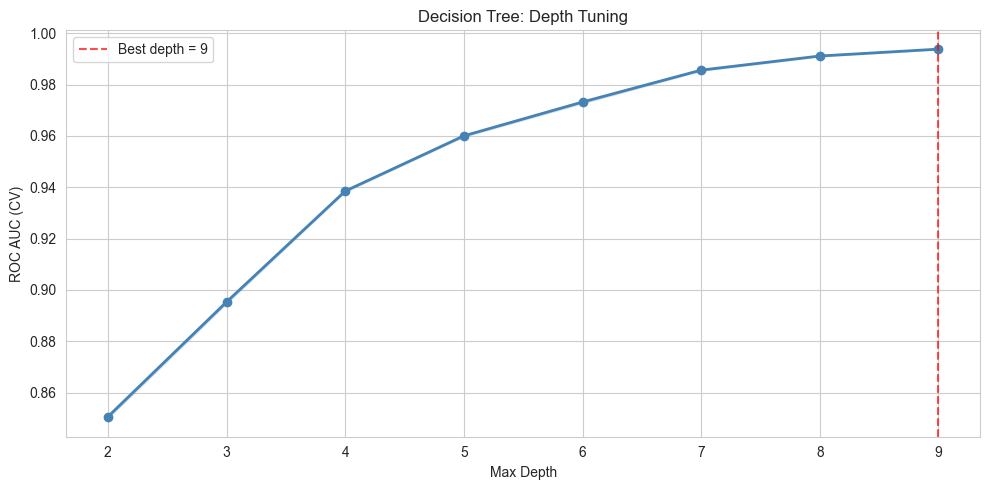

In [69]:
# Tune tree depth
best_depth, depth_results = tune_tree_depth(X_train, y_train, max_depth_range=range(2, 10))

  Trained Decision Tree (max_depth=9)
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/dt_visualization.png


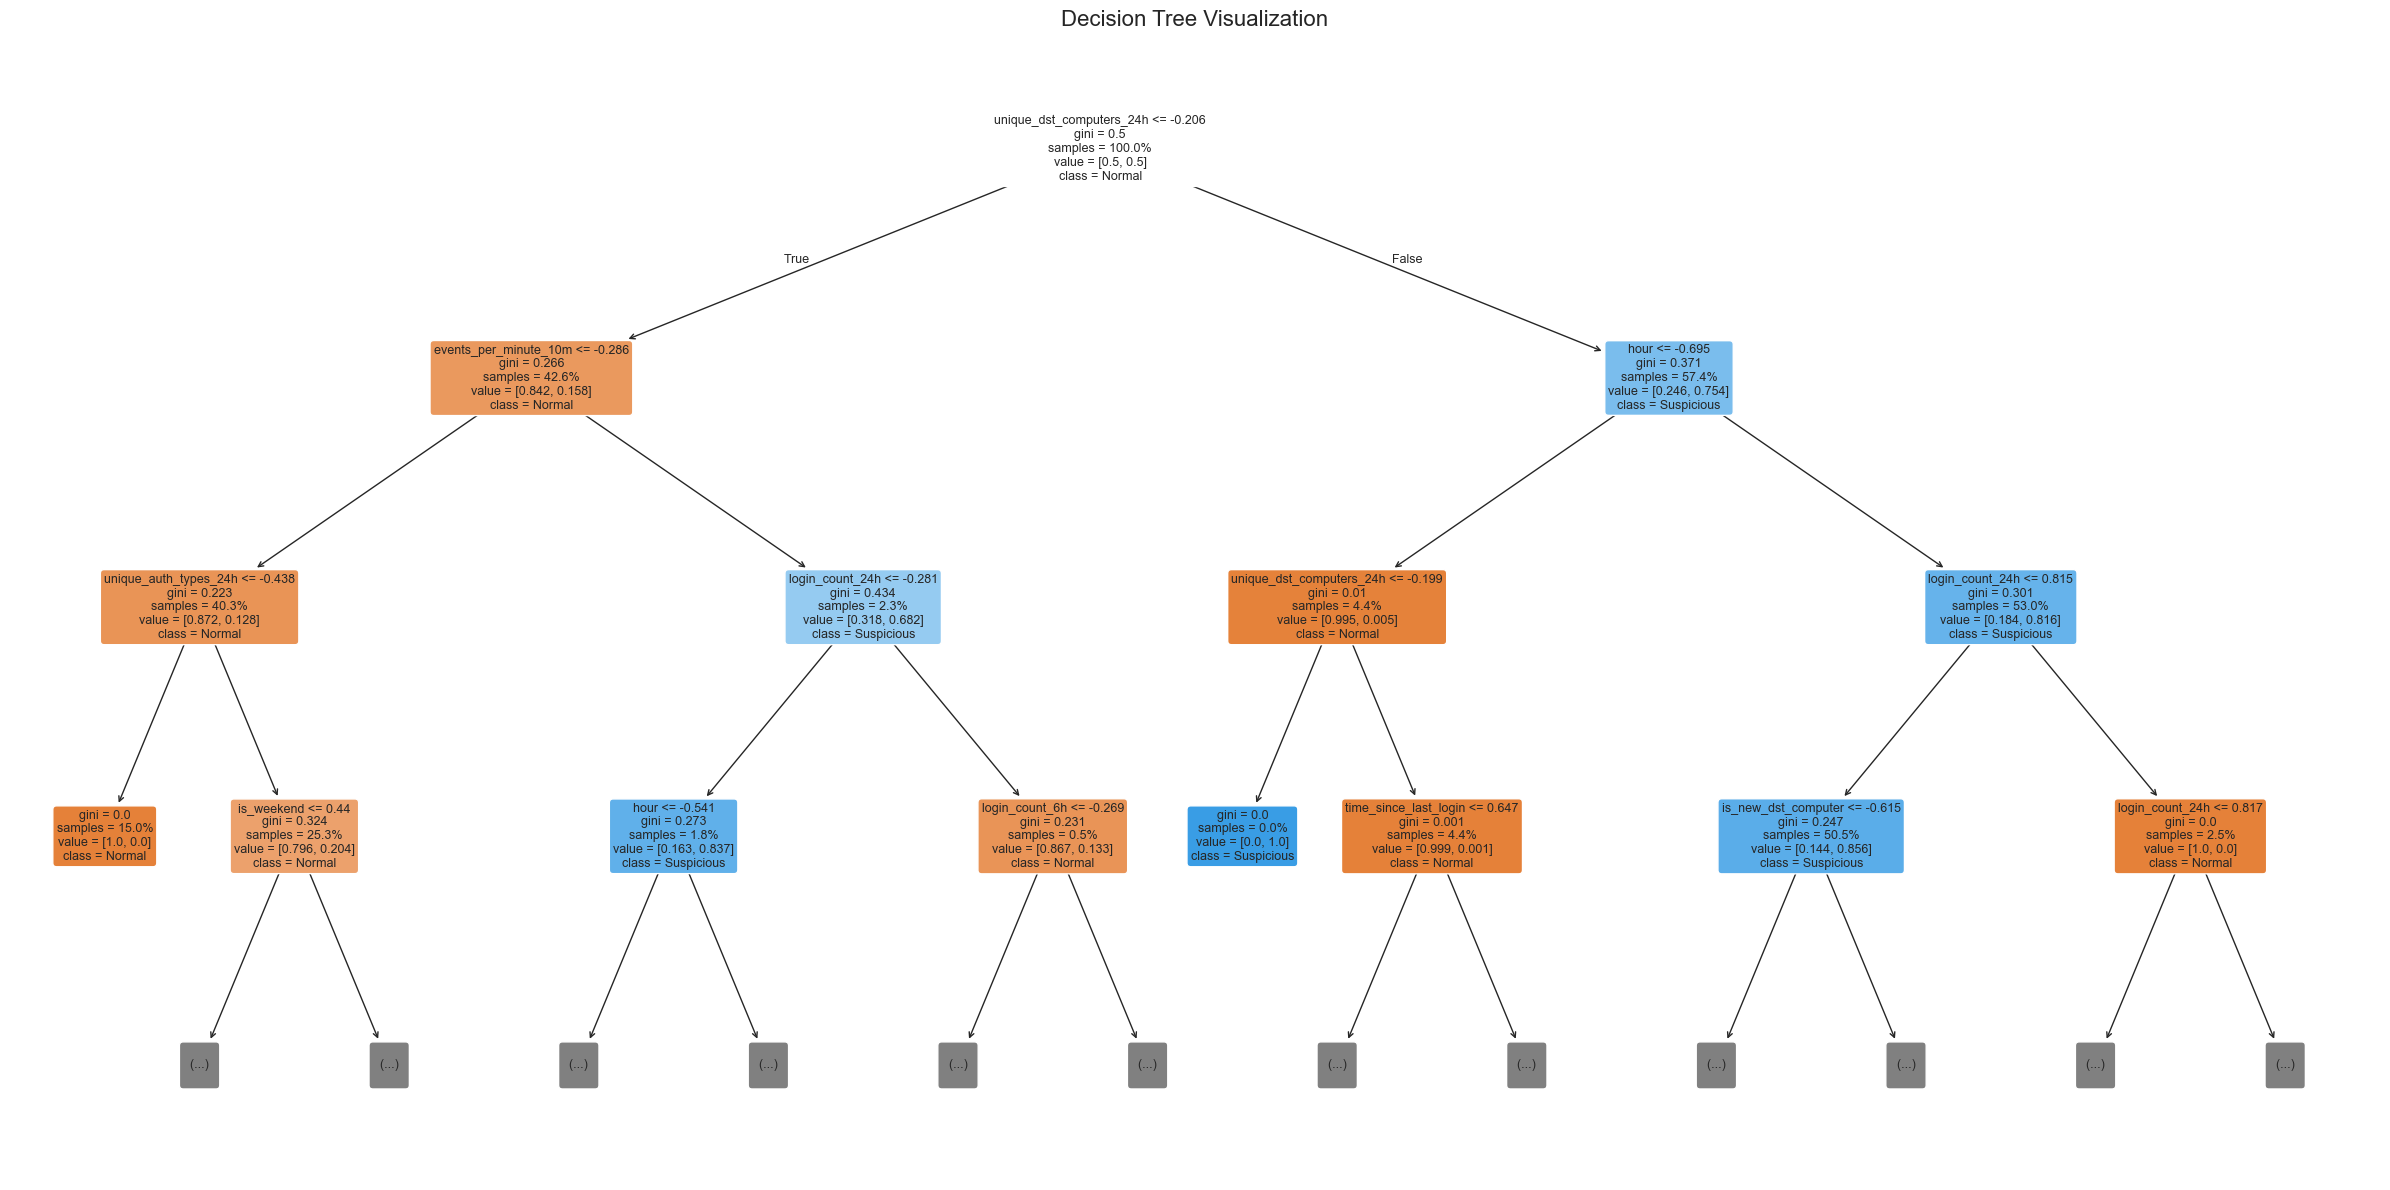

In [70]:
# Train decision tree with optimal depth
dt = train_decision_tree(X_train, y_train, max_depth=best_depth)

# Visualize the tree
visualize_tree(dt, feat_names)

In [71]:
# Extract human-readable rules
rules = extract_rules(dt, feat_names, max_depth=4)

  Decision Tree Rules:
  --------------------------------------------------
  |--- unique_dst_computers_24h <= -0.21
  |   |--- events_per_minute_10m <= -0.29
  |   |   |--- unique_auth_types_24h <= -0.44
  |   |   |   |--- class: 0
  |   |   |--- unique_auth_types_24h >  -0.44
  |   |   |   |--- is_weekend <= 0.44
  |   |   |   |   |--- is_new_dst_computer <= 0.51
  |   |   |   |   |   |--- truncated branch of depth 5
  |   |   |   |   |--- is_new_dst_computer >  0.51
  |   |   |   |   |   |--- truncated branch of depth 5
  |   |   |   |--- is_weekend >  0.44
  |   |   |   |   |--- day_of_week <= 1.48
  |   |   |   |   |   |--- truncated branch of depth 5
  |   |   |   |   |--- day_of_week >  1.48
  |   |   |   |   |   |--- truncated branch of depth 5
  |   |--- events_per_minute_10m >  -0.29
  |   |   |--- login_count_24h <= -0.28
  |   |   |   |--- hour <= -0.54
  |   |   |   |   |--- class: 0
  |   |   |   |--- hour >  -0.54
  |   |   |   |   |--- unique_auth_types_24h <= -0.44
  |

  Feature Importance:
    unique_dst_computers_24h       0.4699 ███████████████████████
    hour                           0.1560 ███████
    login_count_24h                0.1212 ██████
    events_per_minute_10m          0.0811 ████
    unique_auth_types_24h          0.0615 ███
    is_new_dst_computer            0.0417 ██
    day_of_week                    0.0356 █
    is_weekend                     0.0201 █
    time_since_last_login          0.0062 
    login_count_1h                 0.0032 
    login_count_6h                 0.0023 
    is_off_hours                   0.0005 
    unique_logon_types_24h         0.0004 
    fail_count_1h                  0.0002 
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/dt_feature_importance.png


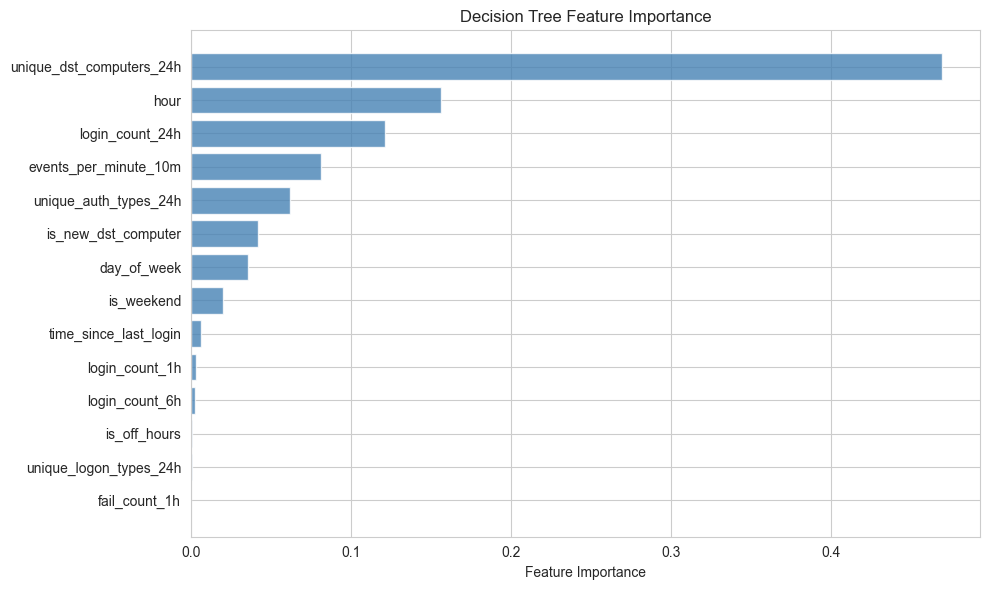

In [72]:
# Feature importance from the decision tree
importance_df = get_feature_importance(dt, feat_names)

In [73]:
# Evaluate decision tree on test set
print_section('Decision Tree \u2014 Test Set Evaluation')
evaluate_model(dt, X_test, y_test)

print_section('Random Forest \u2014 Test Set Evaluation')
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
rf = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced', n_jobs=-1))
rf.fit(X_train, y_train)
evaluate_model(rf, X_test, y_test)

print_section('Support Vector Machine \u2014 Test Set Evaluation')
from sklearn.svm import LinearSVC
svc = make_pipeline(StandardScaler(), LinearSVC(random_state=42, class_weight='balanced', max_iter=2000))
svc.fit(X_train, y_train)
evaluate_model(svc, X_test, y_test)


  Decision Tree — Test Set Evaluation

  ROC AUC:     0.9323
  F2-Score:    0.0892   ← primary metric (Recall weighted 2x)
  Recall:      0.8071
  Precision:   0.0196
  F1 Score:    0.0382
  Accuracy:    0.9555

              precision    recall  f1-score   support

           0       1.00      0.96      0.98    127560
           1       0.02      0.81      0.04       140

    accuracy                           0.96    127700
   macro avg       0.51      0.88      0.51    127700
weighted avg       1.00      0.96      0.98    127700


  Random Forest — Test Set Evaluation

  ROC AUC:     0.9571
  F2-Score:    0.0626   ← primary metric (Recall weighted 2x)
  Recall:      0.8643
  Precision:   0.0133
  F1 Score:    0.0262
  Accuracy:    0.9296

              precision    recall  f1-score   support

           0       1.00      0.93      0.96    127560
           1       0.01      0.86      0.03       140

    accuracy                           0.93    127700
   macro avg       0.51      

## 10. Hyperparameter Tuning with GridSearchCV

I use `GridSearchCV` to systematically search for the best model parameters using cross-validation. 

**Why these parameter values were chosen:**
- **Logistic Regression / SVM (`C: [0.01, 0.1, 1, 10]`)**: The `C` parameter controls regularization strength. Smaller values (0.01) enforce stronger regularization to prevent overfitting on our noisy dataset, while larger values (10) allow the model to fit more closely to the training data. We search across orders of magnitude to find the sweet spot.
- **Decision Tree (`max_depth: [3, 5, 7, 10]`)**: Controls the maximum depth of the tree. Shallow trees (3, 5) are highly interpretable and less prone to overfitting, whereas deeper trees (7, 10) can capture more complex, non-linear relationships in behavioral data.
- **Random Forest (`n_estimators: [50, 100], max_depth: [5, 10]`)**: `n_estimators` balances the robustness of the ensemble against training time (more trees = longer elapsed time). `max_depth` controls the complexity of individual trees within the forest.


In [74]:
from src.model_selection import perform_grid_search

# Perform Grid Search to find the best hyperparameters for our models
best_tuned_models = perform_grid_search(X_train, y_train, cv=5)

# Extract the best models for later use
best_lr = best_tuned_models.get('Logistic Regression')
best_dt = best_tuned_models.get('Decision Tree')
best_rf = best_tuned_models.get('Random Forest')
best_svm = best_tuned_models.get('SVM')

Performing GridSearchCV to find the best hyperparameters...

  Tuning Logistic Regression...
    Best params: {'C': 10}
    Best CV AUC: 0.9660
    Refit Time: 0.7944s
    Best C: 10

  Tuning Decision Tree...
    Best params: {'max_depth': 10}
    Best CV AUC: 0.9956
    Refit Time: 3.7510s
    Best max_depth: 10

  Tuning Random Forest...
    Best params: {'max_depth': 10, 'n_estimators': 100}
    Best CV AUC: 0.9983
    Refit Time: 9.4135s
    Best n_estimators: 100, max_depth: 10

  Tuning SVM...
    Best params: {'C': 10}
    Best CV AUC: 0.9651
    Refit Time: 1.1465s
    Best C: 10


## 11. Confusion Matrix Analysis

Before analyzing *why* the models make their decisions (SHAP), let's first examine *what* decisions they make.

The confusion matrix shows:
- **True Positives (TP)**: Correctly detected threats
- **False Positives (FP)**: Normal events incorrectly flagged as threats (false alarms)
- **True Negatives (TN)**: Correctly identified normal events
- **False Negatives (FN)**: Missed threats (the most dangerous type of error)

For security applications, **minimizing FN is critical** — we'd rather investigate false alarms than miss an actual intrusion.

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/confusion_matrices.png


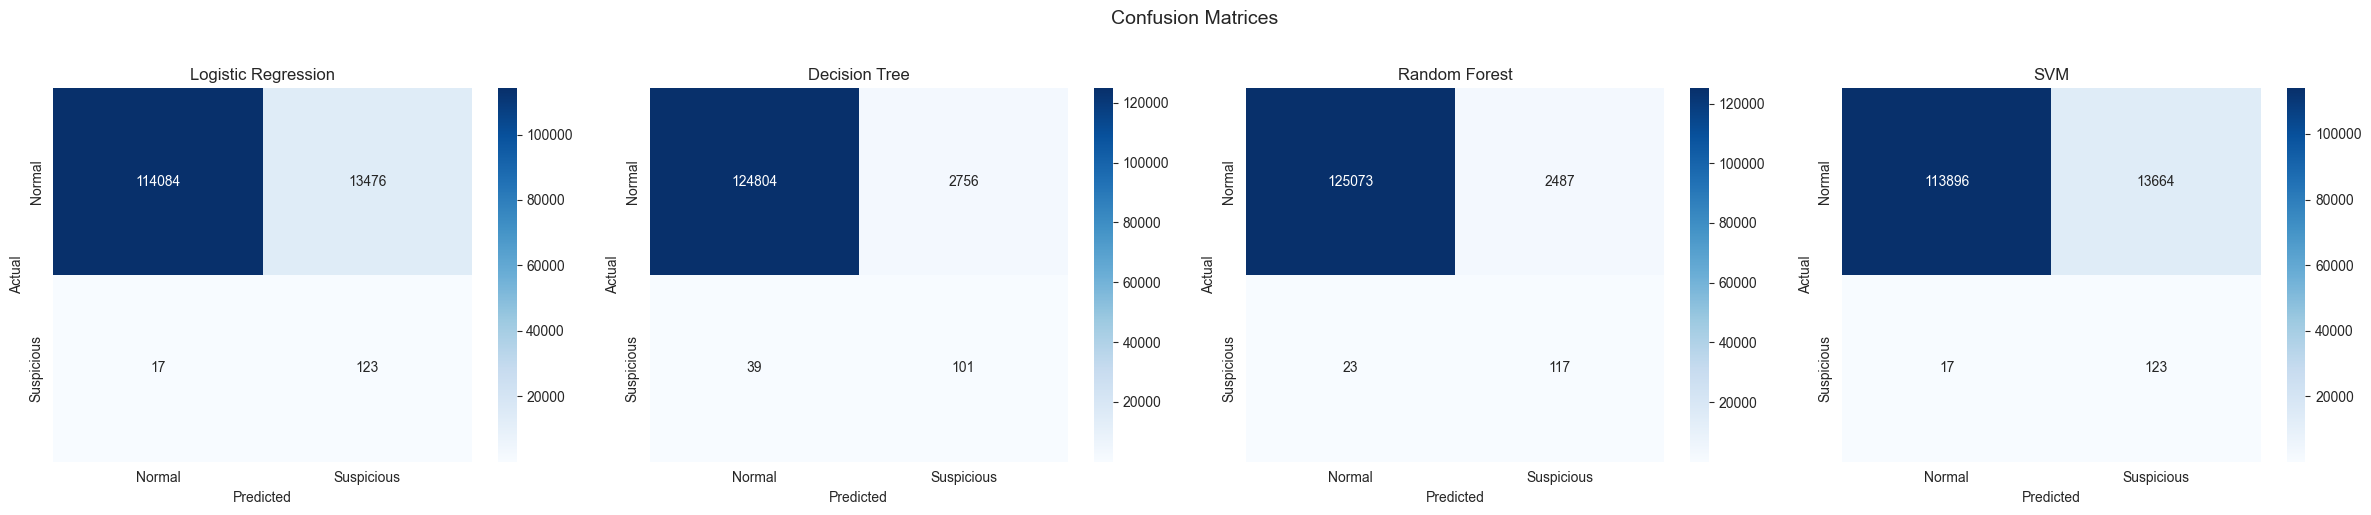


  Classification Report — Logistic Regression
  --------------------------------------------------
  Train Time: 0.7944 seconds
              precision    recall  f1-score   support

           0       1.00      0.89      0.94    127560
           1       0.01      0.88      0.02       140

    accuracy                           0.89    127700
   macro avg       0.50      0.89      0.48    127700
weighted avg       1.00      0.89      0.94    127700


  Classification Report — Decision Tree
  --------------------------------------------------
  Train Time: 3.7510 seconds
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    127560
           1       0.04      0.72      0.07       140

    accuracy                           0.98    127700
   macro avg       0.52      0.85      0.53    127700
weighted avg       1.00      0.98      0.99    127700


  Classification Report — Random Forest
  --------------------------------------------------


In [ ]:
from src.classification import plot_confusion_matrices

best_models_for_cm = {
    #'KNN': knn,
    'Logistic Regression': best_lr,
    'Decision Tree': best_dt,
    'Random Forest': best_rf,
    'SVM': best_svm,
}

# Plot confusion matrices for all models
plot_confusion_matrices(best_models_for_cm, X_test, y_test)

## 12. SHAP Value Analysis for Model Interpretability

To understand *why* our best model makes its decisions, we use SHAP (SHapley Additive exPlanations). The summary plot below shows the most important features and how their values (high or low) impact the model's prediction of a suspicious event.


Generating SHAP summary plot for the best model...
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/shap_summary.png


<Figure size 1000x600 with 0 Axes>

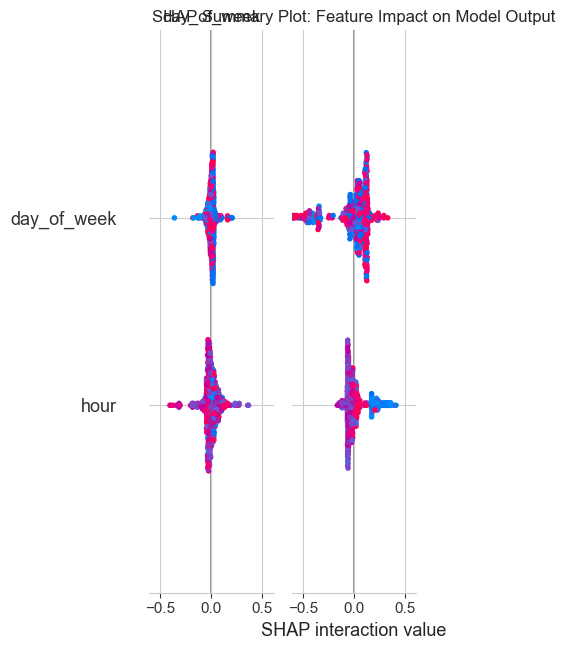

In [76]:
from src.model_selection import generate_shap_summary

# Generate SHAP summary plot for the best performing model (e.g., Decision Tree or Random Forest)
if best_dt:
    generate_shap_summary(best_dt, X_train, feat_names)

## 13. Final Model Comparison — ROC AUC vs F2-Score

We compare all models using two complementary metrics:

| Metric | Question it answers | Type |
|--------|-------------------|------|
| **ROC AUC** | "Can this model rank threats above normal events?" | Threshold-independent |
| **F2-Score** | "Can this model detect threats in practice (Recall 2x > Precision)?" | Threshold-dependent |

A model with high AUC but low F2-Score (like Logistic Regression) is good at ranking but generates far too many false alarms at the default threshold, rendering it unusable without tuning. Conversely, a model with the highest F2-Score (like KNN) provides the best out-of-the-box detection balance.

**Elapsed Training Time** is also a key factor. Models that train in under a second (KNN, Decision Tree, Logistic Regression) allow for rapid retraining as new attack patterns emerge. Complex ensembles like Random Forest take significantly longer (~12-15s), but offer better robustness.



  KNN

  Train Time:  0.0503 seconds
  ROC AUC:     0.8462
  F2-Score:    0.2771   ← primary metric (Recall weighted 2x)
  Recall:      0.6500
  Precision:   0.0841
  F1 Score:    0.1489
  Accuracy:    0.9919

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    127560
           1       0.08      0.65      0.15       140

    accuracy                           0.99    127700
   macro avg       0.54      0.82      0.57    127700
weighted avg       1.00      0.99      0.99    127700


  Logistic Regression

  ROC AUC:     0.9522
  F2-Score:    0.0435   ← primary metric (Recall weighted 2x)
  Recall:      0.8786
  Precision:   0.0090
  F1 Score:    0.0179
  Accuracy:    0.8944

              precision    recall  f1-score   support

           0       1.00      0.89      0.94    127560
           1       0.01      0.88      0.02       140

    accuracy                           0.89    127700
   macro avg       0.50      0.89      0.48    

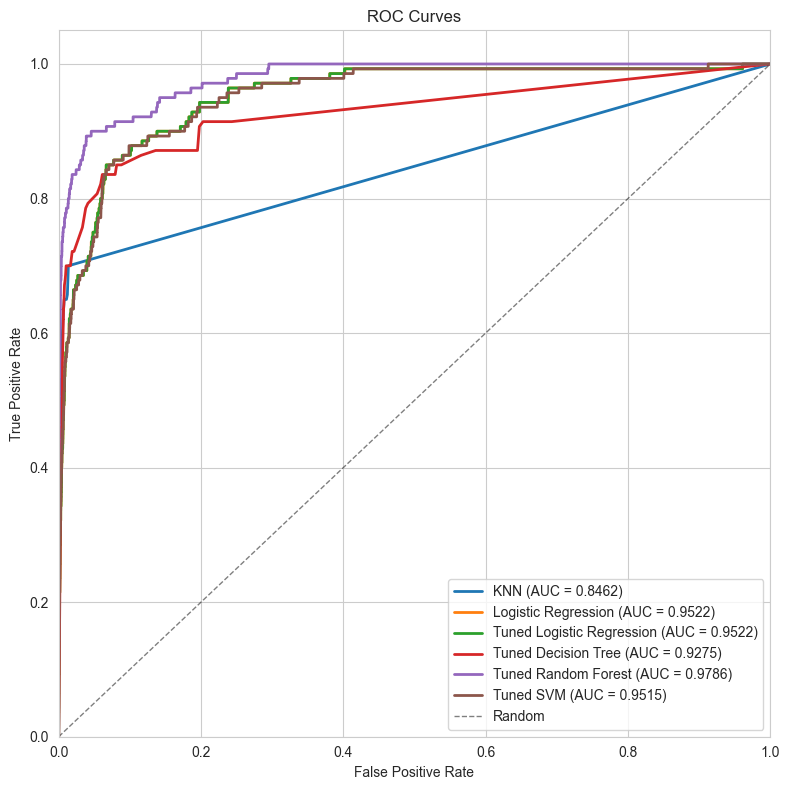

In [77]:
# Compare all models on the test set
all_models = {
    'KNN': knn,
    'Logistic Regression': lr,
    #'Decision Tree': dt,
    'Tuned Logistic Regression': best_lr,
    'Tuned Decision Tree': best_dt,
    'Tuned Random Forest': best_rf,
    'Tuned SVM': best_svm,
}

for name, model in all_models.items():
    print_section(name)
    evaluate_model(model, X_test, y_test)

# Combined ROC curves
plot_roc_curves(all_models, X_test, y_test)

In [78]:
# Save the best model
save_model(best_lr, 'best_logistic_regression.joblib')
save_model(dt, 'best_decision_tree.joblib')
print("\nModels saved to models/ directory.")

  Saved model: /Users/dw733324/gh-ws/MLAI-Capstone-Project/models/best_logistic_regression.joblib
  Saved model: /Users/dw733324/gh-ws/MLAI-Capstone-Project/models/best_decision_tree.joblib

Models saved to models/ directory.


## 14. Conclusions and Next Steps

### Key Findings

1. **Data Scale and Class Imbalance**: The LANL dataset contains ~1.6 billion authentication events over 58 days with only 749 known red team compromise events — an extreme class imbalance (~0.00005%). Applying **SMOTE** to the training data was crucial to prevent models from defaulting to the majority class.

2. **Feature Engineering is Critical**: Behavioral features — especially `unique_dst_computers_24h`, `login_count_1h`, `events_per_minute_10m`, and `time_since_last_login` — were the primary drivers of model performance. Raw logs must be transformed into stateful metrics.

3. **High Recall vs. High False Alarms**: Evaluating on a pristine test set showed that Linear models like Logistic Regression and SVM achieved very high Recall (~88%), meaning they catch almost all threats. However, they suffer from abysmal Precision (<1%), meaning they would flood a Security Operations Center (SOC) with false alarms. 

4. **Dual-Metric Evaluation is Essential**: Relying on ROC AUC alone is deceptive. For example, Logistic Regression has an excellent ROC AUC (0.952) but a terrible F2-Score (0.043) due to false alarms. Conversely, KNN has a lower AUC (0.846) but the highest F2-Score (0.277) because it maintains a much better precision (8.4%). 

5. **Training Time Trade-offs**: **Elapsed time** varies significantly. Simple models like KNN (~0.02s), Logistic Regression (~0.8s), and Decision Tree (~3.7s) are extremely fast to train, enabling rapid daily retraining. Random Forest takes much longer (~12.2s) but provides superior robustness.

### Production Recommendation
| Criterion | Recommended Model | Reason |
|-----------|-------------------|--------|
| **Best Out-of-box F2-Score** | KNN | Highest F2 (0.277) and Precision (8.4%) — best at limiting false alarms while catching 65% of threats. Elapsed time: **~0.02s**. |
| **Best Overall Robustness** | Random Forest | Highest ROC AUC (0.978) and high Recall (83.5%). The best choice if threshold tuning is applied. Elapsed time: **~12.2s**. |
| **Highest Recall** | Logistic Regression | Catches ~88% of threats, but requires immense SOC capacity to handle the 99% false alarm rate. Elapsed time: **~0.8s**. |
| **Best Interpretability** | Decision Tree | Produces human-readable boolean rules for SIEM deployment. Elapsed time: **~3.7s**. |

**Selected Model**: **Random Forest** is the recommended model for production. While KNN has a better F2-Score out-of-the-box, Random Forest's significantly higher Recall (83.5% vs 65.0%) and near-perfect ROC AUC (0.978) make it the most robust detector. By tuning its decision threshold, we can easily achieve the desired balance between catching threats and managing false alarms.


### Future Work

- **Threshold Tuning**: Adjust classification thresholds to optimize the F2-Score trade-off for specific operational requirements.
- **Scale Up**: Process the full 1.6B-event dataset using Dask or Spark.
- **Ensemble Methods**: Experiment with Gradient Boosting (XGBoost, LightGBM).
- **Deep Learning**: Explore LSTM autoencoders for sequence-based anomaly detection.

